# Deffuant model: how bounded confidence shapes opinions

Learning objective: see how random pairwise compromise can reduce disagreement while leaving distinct opinion groups.

People may be willing to reconsider their opinions only when a neighbor's view is sufficiently close. A network lets us ask theoretical questions such as:

- Does local compromise lead to consensus?
- How does willingness to interact affect the final opinions?
- Can disagreement persist even on a connected social network?

The value of the model is that it makes these assumptions explicit and lets us examine their consequences.

## The Deffuant–Weisbuch model

Each agent $i$ has a continuous opinion $x_i(\tau)\in[0,1]$. At each attempted interaction, choose one undirected network edge $\{i,j\}$ uniformly at random.

The pair compromises only when

$$
|x_i(\tau)-x_j(\tau)| < \epsilon.
$$

If compatible, both opinions change simultaneously using their old values:

$$
\begin{aligned}
x_i(\tau+1)&=x_i(\tau)+\mu\bigl[x_j(\tau)-x_i(\tau)\bigr],\\
x_j(\tau+1)&=x_j(\tau)+\mu\bigl[x_i(\tau)-x_j(\tau)\bigr].
\end{aligned}
$$

Otherwise neither opinion changes. All other agents keep their opinions. The confidence bound $\epsilon$ controls willingness to interact; the compromise parameter $\mu$ controls how far each agent moves.

### Conventions used here

- **Opinion space:** continuous values in $[0,1]$.
- **Population:** 100 agents by default; adjustable through N_AGENTS.
- **Topology:** one fixed, simple, connected, undirected Watts–Strogatz network, using the same settings as the DeGroot notebook.
- **Initial state:** independent uniform draws on $[0,1]$ with a visible fixed seed.
- **Pair selection:** sample uniformly from all network edges, with replacement; rejected pairs still count as attempts.
- **Update schedule:** asynchronous across pairs; both members of a selected pair update from their old values.
- **Confidence boundary:** strict inequality $|x_i-x_j|<\epsilon$; equality is rejected.
- **Time:** $\tau$ counts attempted interactions; one plotted sweep contains N_AGENTS attempts. It is not a synchronous DeGroot round, and agents need not participate equally often.
- **Simulation horizon:** exactly N_SWEEPS, recording the initial state and every sweep boundary; no early stopping.
- **Observables:** opinion trajectories, opinion range, and final opinion distribution.
- **Consensus criterion:** global opinion range strictly smaller than CONSENSUS_TOLERANCE, evaluated at recorded times.
- **Parameter ranges:** integer N_AGENTS >= 3 and N_SWEEPS >= 0; integer $1\leq$ NEIGHBORS_ON_EACH_SIDE $<N/2$; rewiring probability and each confidence bound in $[0,1]$; $0<\mu\leq1/2$; CONSENSUS_TOLERANCE > 0.

This is the network-restricted version of the Deffuant model. The original well-mixed pair selection is recovered on a complete graph. Isolated agents, if supplied to the simulation, never participate and keep their opinions.

Symmetric compromise preserves the arithmetic mean in every realization, even when some interactions are rejected. If global consensus occurs, its limiting value is that initial mean. Connectedness of the social network alone does not guarantee consensus when confidence restricts interactions.

In [1]:
import random

import igraph as ig
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Adjustable parameters
N_AGENTS = 100
N_SWEEPS = 500
NEIGHBORS_ON_EACH_SIDE = 3
REWIRING_PROBABILITY = 0.10
CONFIDENCE_BOUND = 0.20
COMPARISON_CONFIDENCE_BOUND = 0.60
COMPROMISE_PARAMETER = 0.50
CONSENSUS_TOLERANCE = 0.01

# Match DeGroot's topology and initial opinions; separate the interaction RNG.
NETWORK_SEED = 2026
OPINION_SEED = 2027
LAYOUT_SEED = 2028
INTERACTION_SEED = 2029

assert isinstance(N_AGENTS, int) and N_AGENTS >= 3
assert isinstance(N_SWEEPS, int) and N_SWEEPS >= 0
assert isinstance(NEIGHBORS_ON_EACH_SIDE, int)
assert 1 <= NEIGHBORS_ON_EACH_SIDE < N_AGENTS / 2
assert 0 <= REWIRING_PROBABILITY <= 1
assert 0 <= CONFIDENCE_BOUND <= 1
assert 0 <= COMPARISON_CONFIDENCE_BOUND <= 1
assert 0 < COMPROMISE_PARAMETER <= 0.5
assert CONSENSUS_TOLERANCE > 0

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

## 1. Create the social network

We use `igraph` to create, store, lay out, and draw a small-world network. The parameter `NEIGHBORS_ON_EACH_SIDE = 3` starts each agent with three lattice neighbors on either side.

The `python-igraph` generator uses a small-world rewiring variant. This synthetic topology is a convenient theoretical influence structure, not a reconstruction of a real social network.

The force-directed layout affects only the drawing, not the interaction rule or dynamics. Fixed seeds make the generated network and layout reproducible within the specified software environment; results may differ across library versions.

In [2]:
# igraph uses this seeded generator for reproducible rewiring.
ig.set_random_number_generator(random.Random(NETWORK_SEED))

graph_ig = ig.Graph.Watts_Strogatz(
    dim=1,
    size=N_AGENTS,
    nei=NEIGHBORS_ON_EACH_SIDE,
    p=REWIRING_PROBABILITY,
)

assert not graph_ig.is_directed()
assert graph_ig.vcount() == N_AGENTS
assert graph_ig.is_simple(), "The influence network must be simple."
assert graph_ig.is_connected(), "The influence network must be connected."
assert graph_ig.vs.indices == list(range(N_AGENTS))

# Seed the starting coordinates independently from the network draw.
ig.set_random_number_generator(random.Random(LAYOUT_SEED))
layout_rng = np.random.default_rng(LAYOUT_SEED)
layout_start = layout_rng.uniform(-1.0, 1.0, size=(N_AGENTS, 2))
layout = graph_ig.layout_fruchterman_reingold(
    seed=layout_start.tolist(),
)
assert len(layout) == N_AGENTS

opinion_rng = np.random.default_rng(OPINION_SEED)
initial_opinions = opinion_rng.uniform(0.0, 1.0, size=N_AGENTS)

print(f"Agents: {graph_ig.vcount()}")
print(f"Connections: {graph_ig.ecount()}")
print(f"Connected: {graph_ig.is_connected()}")

Agents: 100
Connections: 300
Connected: True


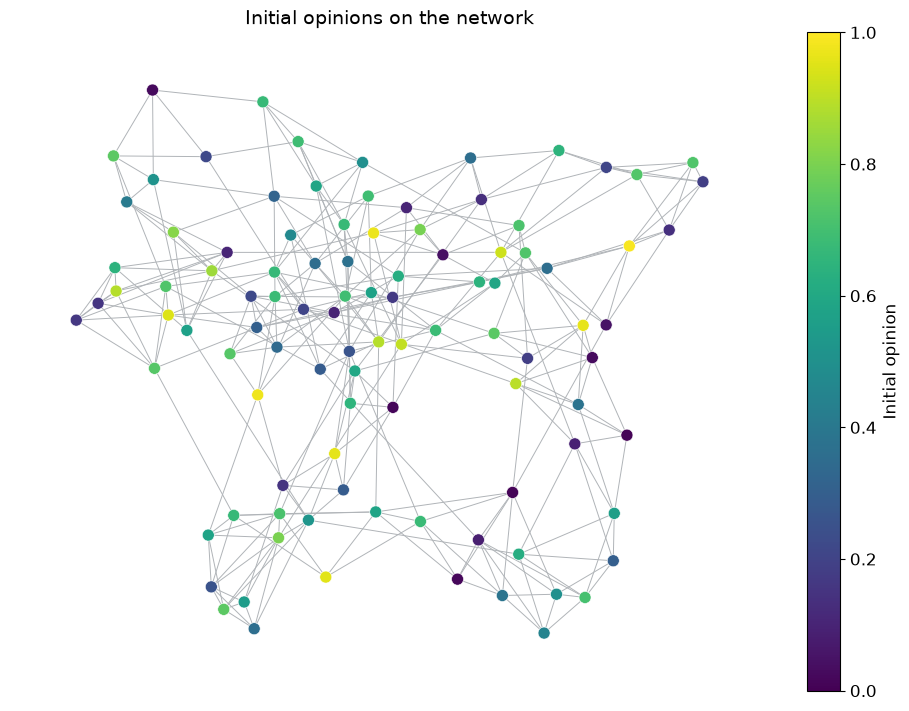

In [3]:
opinion_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
opinion_cmap = plt.colormaps["viridis"]
opinion_color_scale = plt.cm.ScalarMappable(
    norm=opinion_norm,
    cmap=opinion_cmap,
)


def draw_opinion_network(ax, opinions, title, vertex_size):
    """Draw opinions on the igraph network using vertex-ID order."""
    vertex_colors = [
        mcolors.to_hex(opinion_cmap(opinion_norm(value)))
        for value in opinions
    ]
    assert len(vertex_colors) == graph_ig.vcount()

    ig.plot(
        graph_ig,
        target=ax,
        layout=layout,
        vertex_color=vertex_colors,
        vertex_size=vertex_size,
        vertex_frame_color="white",
        vertex_frame_width=0.4,
        vertex_label=None,
        edge_color="#b0b4b8",
        edge_width=0.7,
        autocurve=False,
    )
    ax.set_title(title)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
draw_opinion_network(
    ax,
    initial_opinions,
    "Initial opinions on the network",
    vertex_size=12,
)
fig.colorbar(opinion_color_scale, ax=ax, label="Initial opinion")
plt.show()

## 2. Translate the theory into code

The edge list tells us which pairs can meet. The confidence test uses the opinions at the moment of interaction.

We cache both old values before updating either agent. The pair sum is unchanged:

$$
x_i(\tau+1)+x_j(\tau+1)=x_i(\tau)+x_j(\tau).
$$

At $\mu=1/2$, a compatible pair meets at its midpoint. Smaller values produce partial compromise. No change occurs at $\epsilon=0$ under the strict threshold convention.

In [4]:
edge_array = np.asarray(graph_ig.get_edgelist(), dtype=int).reshape(-1, 2)
initial_mean = initial_opinions.mean()


def compromise_pair(opinions, i, j, confidence_bound, mu):
    """Update a compatible pair in place from its two old opinions."""
    old_i, old_j = opinions[i], opinions[j]
    if abs(old_i - old_j) < confidence_bound:
        opinions[i] = old_i + mu * (old_j - old_i)
        opinions[j] = old_j + mu * (old_i - old_j)


# Hand-check partial compromise: 0 and 0.5 become 0.125 and 0.375.
test_pair = np.array([0.0, 0.5])
compromise_pair(test_pair, 0, 1, confidence_bound=0.75, mu=0.25)
assert np.allclose(test_pair, [0.125, 0.375])
assert np.isclose(test_pair.sum(), 0.5)

# Exactly on the confidence boundary: reject the interaction.
boundary_pair = np.array([0.0, 0.5])
compromise_pair(boundary_pair, 0, 1, confidence_bound=0.5, mu=0.5)
assert np.array_equal(boundary_pair, [0.0, 0.5])

print(f"Initial arithmetic mean: {initial_mean:.6f}")

Initial arithmetic mean: 0.501849


## 3. Run asynchronous Deffuant updates

Each sweep samples N_AGENTS edges independently with replacement. These attempts execute sequentially, so later pairs see changes made by earlier pairs.

The function keeps the input opinions intact and records one snapshot per sweep. Drawing every edge index before processing a sweep also lets us reuse precisely the same attempted interactions in the confidence comparison.

In [5]:
def simulate_deffuant(edges, initial_state, n_sweeps, confidence_bound, mu, rng):
    """Return opinions at sweep boundaries, including the initial state."""
    opinions = np.asarray(initial_state, dtype=float).copy()
    assert opinions.ndim == 1 and opinions.size > 0
    assert np.all(np.isfinite(opinions)) and np.all((0 <= opinions) & (opinions <= 1))
    assert isinstance(n_sweeps, int) and n_sweeps >= 0
    assert 0 <= confidence_bound <= 1 and 0 < mu <= 0.5
    assert edges.ndim == 2 and edges.shape[1] == 2
    assert np.issubdtype(edges.dtype, np.integer)
    assert np.all((0 <= edges) & (edges < len(opinions)))
    assert np.all(edges[:, 0] != edges[:, 1])

    history = np.empty((n_sweeps + 1, len(opinions)))
    history[0] = opinions

    for sweep in range(1, n_sweeps + 1):
        if len(edges):
            edge_indices = rng.integers(len(edges), size=len(opinions))
            for edge_index in edge_indices:
                i, j = edges[edge_index]
                compromise_pair(opinions, i, j, confidence_bound, mu)
        history[sweep] = opinions

    return history


def check_averaging_invariants(history, initial_state):
    """Check conservation and convex averaging for a recorded trajectory."""
    assert np.all(np.isfinite(history))
    assert np.allclose(history.mean(axis=1), initial_state.mean(), atol=1e-12, rtol=0)
    assert history.min() >= initial_state.min() - 1e-12
    assert history.max() <= initial_state.max() + 1e-12
    assert np.all(np.diff(np.ptp(history, axis=1)) <= 1e-12)
    assert np.all(np.diff(np.var(history, axis=1)) <= 1e-12)


opinion_history = simulate_deffuant(
    edge_array, initial_opinions, N_SWEEPS,
    CONFIDENCE_BOUND, COMPROMISE_PARAMETER,
    np.random.default_rng(INTERACTION_SEED),
)
check_averaging_invariants(opinion_history, initial_opinions)
final_opinions = opinion_history[-1]

## 4. Compare the initial and final states

Both panels use the same network layout and color scale. This makes changes in opinions visible without confusing them with changes in node position.

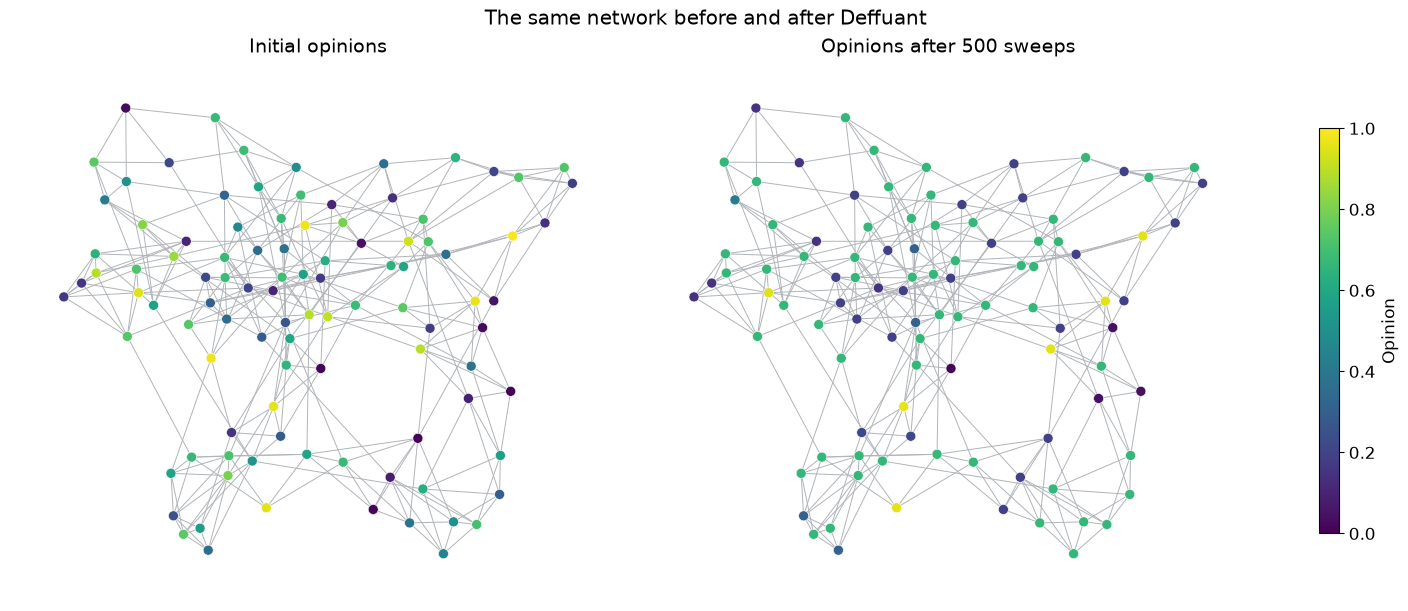

In [6]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    layout="constrained",
)

states = [
    (initial_opinions, "Initial opinions"),
    (final_opinions, f"Opinions after {N_SWEEPS} sweeps"),
]

for ax, (opinions, title) in zip(axes, states):
    draw_opinion_network(
        ax,
        opinions,
        title,
        vertex_size=10,
    )

fig.colorbar(
    opinion_color_scale,
    ax=axes,
    label="Opinion",
    shrink=0.75,
)
fig.suptitle(
    "The same network before and after Deffuant"
)
plt.show()

## 5. A typical analysis: does disagreement disappear?

We follow individual opinions and the global opinion range:

$$
R(t)=\max_i x_i(t)-\min_i x_i(t),
$$

where $t$ is measured in sweeps. Convex compromise cannot increase this range, but confidence restrictions can leave it positive.

The dashed mean line is a conservation reference. It is the consensus value only if consensus occurs. A plateau over a finite observation window does not by itself establish a limiting state or an exact number of opinion clusters.

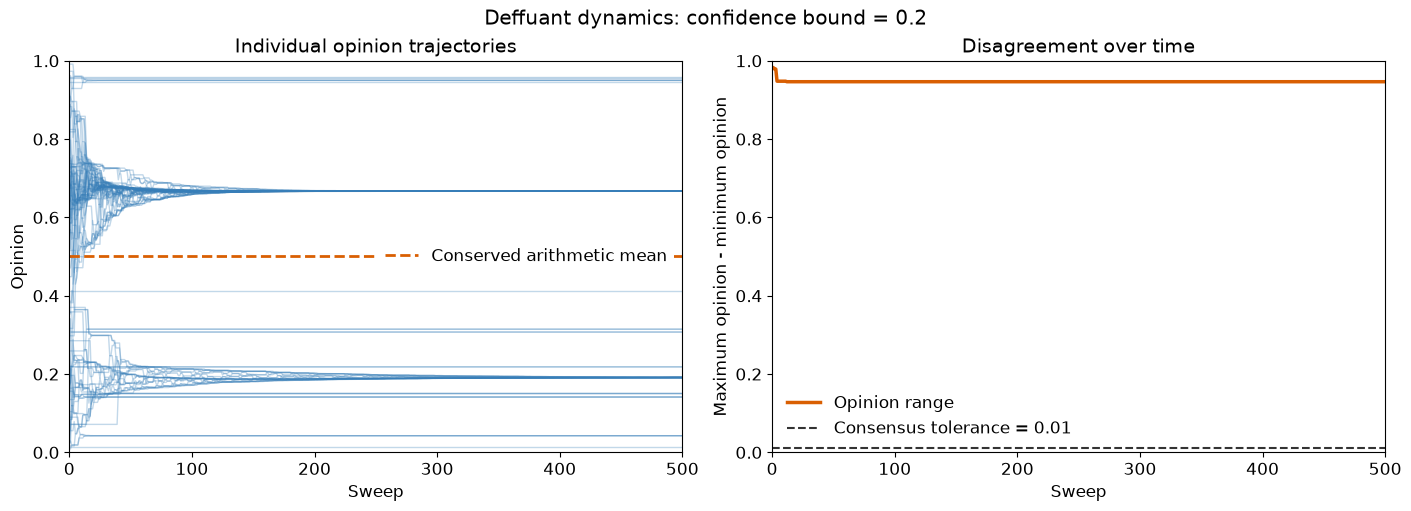

The trajectory did not reach the consensus tolerance.
Initial mean: 0.501849; final mean: 0.501849
Final opinion range: 0.946529
Largest remaining gap on a compatible edge: 0.000691905


In [7]:
sweeps = np.arange(N_SWEEPS + 1)
opinion_range = np.ptp(opinion_history, axis=1)
consensus_sweeps = np.flatnonzero(opinion_range < CONSENSUS_TOLERANCE)
first_consensus_sweep = int(consensus_sweeps[0]) if consensus_sweeps.size else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
axes[0].plot(sweeps, opinion_history, color="#377eb8", alpha=0.30, linewidth=1)
axes[0].axhline(
    initial_mean, color="#d95f02", linestyle="--",
    linewidth=2, label="Conserved arithmetic mean",
)
axes[0].set(
    title="Individual opinion trajectories", xlabel="Sweep", ylabel="Opinion",
    ylim=(0, 1), xlim=(0, max(1, N_SWEEPS)),
)
axes[0].legend(frameon=True, facecolor="white", edgecolor="none", framealpha=1)

axes[1].plot(
    sweeps, opinion_range, color="#d95f02", linewidth=2.5, label="Opinion range",
)
axes[1].axhline(
    CONSENSUS_TOLERANCE, color="#333333", linestyle="--",
    label=f"Consensus tolerance = {CONSENSUS_TOLERANCE}",
)
if first_consensus_sweep is not None:
    axes[1].axvline(
        first_consensus_sweep, color="#377eb8", linestyle=":",
        label=f"First detected: sweep {first_consensus_sweep}",
    )
axes[1].set(
    title="Disagreement over time", xlabel="Sweep",
    ylabel="Maximum opinion - minimum opinion",
    ylim=(0, 1), xlim=(0, max(1, N_SWEEPS)),
)
axes[1].legend(frameon=False)
fig.suptitle(f"Deffuant dynamics: confidence bound = {CONFIDENCE_BOUND:g}")
plt.show()

if first_consensus_sweep is None:
    print("The trajectory did not reach the consensus tolerance.")
else:
    print("First recorded sweep below tolerance:", first_consensus_sweep)
print(f"Initial mean: {initial_mean:.6f}; final mean: {final_opinions.mean():.6f}")
print(f"Final opinion range: {opinion_range[-1]:.6f}")

edge_gaps = np.abs(final_opinions[edge_array[:, 0]] - final_opinions[edge_array[:, 1]])
compatible_gaps = edge_gaps[edge_gaps < CONFIDENCE_BOUND]
print(
    "Largest remaining gap on a compatible edge:",
    f"{np.max(compatible_gaps, initial=0.0):.6g}",
)

## 6. One focused experiment: change the confidence bound

We reuse the same network, initial opinions, compromise parameter, and attempted edge sequence. Only the confidence bound changes. Resetting the interaction generator to the same seed achieves this because sampling never depends on whether an interaction was accepted.

The panels show final opinion distributions using identical histogram bins and scales. Histogram peaks illustrate concentrations at the selected resolution; they are not an exact cluster count. These two seeded examples do not establish a universal threshold for consensus.

Confidence 0.2: final range = 0.946529; consensus detected = False
Confidence 0.6: final range = 0.000000; consensus detected = True


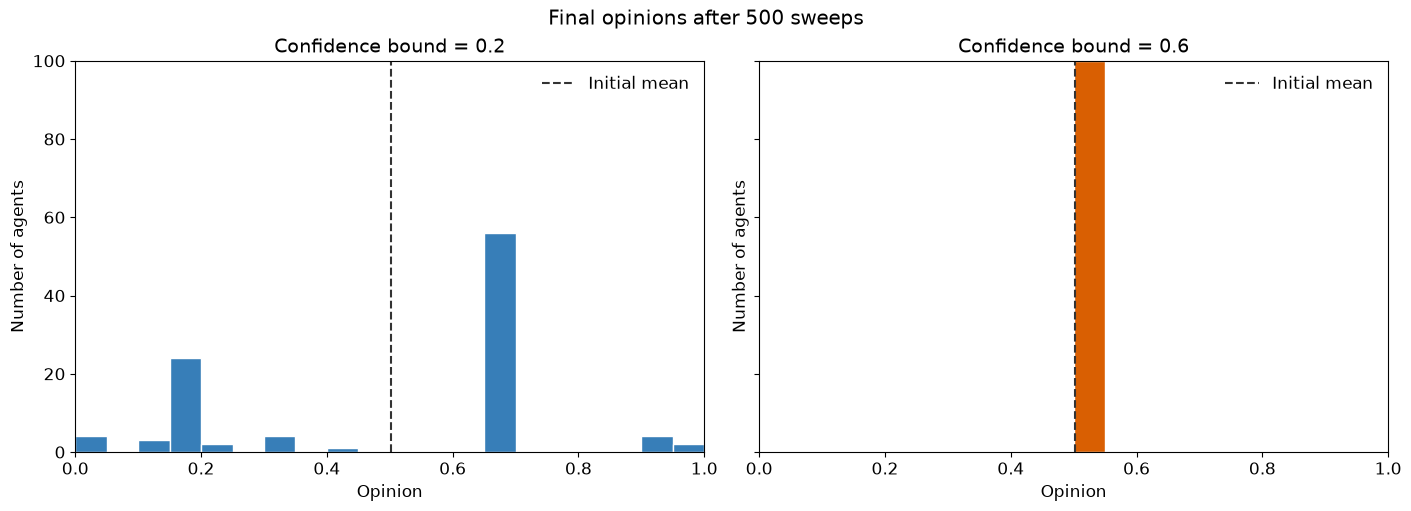

In [8]:
comparison_history = simulate_deffuant(
    edge_array, initial_opinions, N_SWEEPS,
    COMPARISON_CONFIDENCE_BOUND, COMPROMISE_PARAMETER,
    np.random.default_rng(INTERACTION_SEED),
)
check_averaging_invariants(comparison_history, initial_opinions)

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), sharex=True, sharey=True, layout="constrained",
)
scenarios = [
    (CONFIDENCE_BOUND, opinion_history, "#377eb8"),
    (COMPARISON_CONFIDENCE_BOUND, comparison_history, "#d95f02"),
]
bins = np.linspace(0, 1, 21)
for ax, (confidence_bound, history, color) in zip(axes, scenarios):
    ax.hist(history[-1], bins=bins, color=color, edgecolor="white")
    ax.axvline(initial_mean, color="#333333", linestyle="--", label="Initial mean")
    ax.set(
        title=f"Confidence bound = {confidence_bound:g}",
        xlabel="Opinion", ylabel="Number of agents",
        xlim=(0, 1), ylim=(0, N_AGENTS),
    )
    ax.legend(frameon=False)
    final_range = np.ptp(history[-1])
    print(
        f"Confidence {confidence_bound:g}: final range = {final_range:.6f}; "
        f"consensus detected = {final_range < CONSENSUS_TOLERANCE}"
    )
fig.suptitle(f"Final opinions after {N_SWEEPS} sweeps")
plt.show()

## Interpretation and limitations

Symmetric pairwise compromise preserves the arithmetic mean and cannot increase global variance or opinion range. The confidence test controls which social ties actually transmit influence.

The baseline and confidence comparison illustrate how this mechanism can produce different amounts of agreement on the same connected network. A finite simulation can show separated concentrations or near-consensus; it does not prove that every trajectory with these parameters has reached its asymptotic state.

On a sparse network, agents with similar opinions need not be directly linked. Connected components of the social graph, compatible-edge components, and concentrations in opinion space are different objects.

The model omits changing relationships, external information, asymmetric persuasion, individual confidence bounds, and multidimensional beliefs. Its outcomes follow from these theoretical assumptions and should not be interpreted as predictions of real populations.

### Suggested experiments

1. Change `CONFIDENCE_BOUND` within $[0,1]$, keeping the network and seeds fixed.
2. Reduce `COMPROMISE_PARAMETER` and extend `N_SWEEPS` to distinguish slow relaxation from persistent disagreement.
3. Change `REWIRING_PROBABILITY` or `NEIGHBORS_ON_EACH_SIDE`, then compare outcomes across several interaction seeds.

### Original reference

Deffuant, G., Neau, D., Amblard, F., & Weisbuch, G. (2000). *Mixing beliefs among interacting agents*. Advances in Complex Systems, 3(1–4), 87–98. [doi:10.1142/S0219525900000078](https://doi.org/10.1142/S0219525900000078).